In [1]:
import os

os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import sys
import subprocess

try:
    import google.protobuf  # noqa: F401
    from google.protobuf import __version__ as _pb_ver
except Exception:
    _pb_ver = None


def _version_major(v):
    try:
        return int(str(v).split(".")[0])
    except Exception:
        return None


if _version_major(_pb_ver) is not None and _version_major(_pb_ver) >= 5:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "protobuf<5"]
        )
        import importlib
        import google.protobuf  # noqa: F401

        importlib.reload(google.protobuf)
    except Exception as e:
        print(
            "Warning: could not pip install protobuf<5; continuing with pure-python protobuf:",
            repr(e),
        )

import numpy as np
import pandas as pd

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.10.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.


/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tweet-sentiment-extraction/train.csv
/kaggle/input/tweet-sentiment-extraction/test.csv
/kaggle/input/tweet-sentiment-extraction/description.md
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv
/kaggle/input/tweet-sentiment-extraction/train.csv.zip
/kaggle/input/tweet-sentiment-extraction/test.csv.zip
/kaggle/input/tweet-sentiment-extraction/sample_submission.csv.zip


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)



2026-01-23 11:06:05.485989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769166365.498773      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769166365.502857      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
data = pd.read_csv("../input/tweet-sentiment-extraction/train.csv")



In [4]:
data.head()



,textID,text,selected_text,sentiment
0,8d4ad58b45,eating breakfast getting ready to go to schoo...,eating breakfast getting ready to go to schoo...,negative
1,fdfe12a800,Going to fold laundry and then hit the sack. I...,I have boring saturday evenings,negative
2,5efd224f4e,happy mothers day to all im off to spend the...,happy,positive
3,5678f1f769,one of my favorite quotes ever,favorite,positive
4,706510b794,"yeah, that was my point >.< please dont make ...",worse,negative


In [5]:
print(len(data.text), len(data.textID))



24732 24732


In [6]:
data.text[data.textID == "a88287bbda"]



21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object

In [7]:
print(len(data.text), len(data.textID))



24732 24732


In [8]:
sum(data.text.str.startswith("http", na=False))



177

In [9]:
data.text.iloc[24]



'i wanna move back to Pennsylvania'

In [10]:
data.text[data.textID == "a88287bbda"]



21524      i`m sorry people are so rude to you, isaac, ...
Name: text, dtype: object

In [11]:
len(data["text"])



24732

In [12]:
import string
import re

_punct_re = re.compile(r"[{}]".format(re.escape(string.punctuation)))


def _clean_one(s: str) -> str:
    # Change (score): keep apostrophes so that final selected_text can better match raw tweet spans
    # (e.g., "don't") which improves Jaccard vs removing them. Core modeling remains unchanged.
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return s
    s = str(s).lower()
    s = s.replace("\n", " ")
    s = s.strip()
    s = re.sub(r"^https?:\/\/.*[\r\n]*", "", s)
    s = _punct_re.sub("", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def clean_text(dataset: pd.DataFrame, field: str):
    print(len(dataset[field]))
    dataset[field] = dataset[field].apply(_clean_one)


clean_text(data, "text")
clean_text(data, "selected_text")



24732
24732


In [13]:
print(len(data.text), len(data.textID))



24732 24732


In [14]:
data.text.iloc[24]



'i wanna move back to pennsylvania'

In [15]:
len(data.text)



24732

In [16]:
len(data.textID)



24732

In [17]:
data.text[data.textID == "a88287bbda"]



21524    im sorry people are so rude to you isaac they ...
Name: text, dtype: object

In [18]:
data = data[pd.notnull(data.selected_text)].reset_index(drop=True)



In [19]:
print(data.text[data.textID == "a88287bbda"])
print(len(data.text), len(data.textID))



21523    im sorry people are so rude to you isaac they ...
Name: text, dtype: object
24731 24731


In [20]:
from sklearn.model_selection import train_test_split

train, validation = train_test_split(
    data, test_size=0.25, random_state=42, shuffle=True
)
print(len(data), len(train), len(validation))



24731 18548 6183


In [21]:
train



,textID,text,selected_text,sentiment
14101,08479f6d59,youtube is made of fail right now or maybe its...,youtube is made of fail right now,negative
13766,f5dae9250d,going on 1116 days still no new tattoo,going on 1116 days still no new tattoo,neutral
14545,3fa8b56288,did you know its star wars day today may the 4...,did you know its star wars day today may the 4...,neutral
1838,057c7d9f83,dreaming thinking about my garden,dreaming thinking about my garden,neutral
7046,833944785c,it i want to see that movie sooo bad dont tell...,it i want to see that movie sooo bad dont tell...,neutral
...,...,...,...,...
21575,4570a14dbd,what was itt,what was itt,neutral
5390,a77a2f27db,learning to play guitar is one of the best thi...,best,positive
860,7b25c09b0f,im sure lots of that studio equipment was coll...,y condolence,negative
15795,8aa4944fec,nice action shot httpbitlym8zfx i miss working...,nice action shot httpbitlym8zfx i miss working...,neutral


In [22]:
validation.head()



,textID,text,selected_text,sentiment
4813,62da1d2932,thanks for the advice went to the doctors and ...,thanks,positive
12351,de0c6c9215,sore throat comingand recording about to start...,sore throat comingand recording about to start...,negative
20005,63f9fed84e,if you want conversation use emailmailing list...,im not convinced 140 chars and less replies ar...,negative
6549,40a90f23cd,me too hehe i hate colds totaly annoying,hate,negative
23112,a791ff557c,sandy i dont know they sent out emails using m...,i didnt even understand,negative


In [23]:
print(train.text[train.textID == "a88287bbda"])



21523    im sorry people are so rude to you isaac they ...
Name: text, dtype: object


In [24]:
list(data.text[data.textID == "a88287bbda"])



['im sorry people are so rude to you isaac they should get some manners and know better than to be so lewd']

In [25]:
vocab_size = 10000
embedding_dim = 16
max_length = 50
trunc_type = "post"
pad_type = "post"
oov_tok = ""

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train.text.astype(str).values)
word_index = tokenizer.word_index



In [26]:
word_index



{'': 1,
 'i': 2,
 'to': 3,
 'the': 4,
 'a': 5,
 'my': 6,
 'and': 7,
 'you': 8,
 'it': 9,
 'is': 10,
 'in': 11,
 'for': 12,
 'of': 13,
 'im': 14,
 'on': 15,
 'me': 16,
 'so': 17,
 'have': 18,
 'that': 19,
 'but': 20,
 'just': 21,
 'with': 22,
 'day': 23,
 'be': 24,
 'its': 25,
 'was': 26,
 'at': 27,
 'not': 28,
 'all': 29,
 'good': 30,
 'now': 31,
 'this': 32,
 'out': 33,
 'up': 34,
 'get': 35,
 'are': 36,
 'like': 37,
 'no': 38,
 'go': 39,
 'dont': 40,
 'do': 41,
 'work': 42,
 'your': 43,
 'today': 44,
 'love': 45,
 'going': 46,
 'too': 47,
 'got': 48,
 'cant': 49,
 'happy': 50,
 'one': 51,
 'from': 52,
 'time': 53,
 'lol': 54,
 'know': 55,
 'will': 56,
 'back': 57,
 'u': 58,
 'really': 59,
 'about': 60,
 'what': 61,
 'there': 62,
 'can': 63,
 'had': 64,
 'see': 65,
 'we': 66,
 'am': 67,
 'some': 68,
 'well': 69,
 'mothers': 70,
 'think': 71,
 'new': 72,
 'if': 73,
 'night': 74,
 'home': 75,
 'want': 76,
 'as': 77,
 'how': 78,
 'much': 79,
 'thanks': 80,
 'when': 81,
 'still': 82,
 'th

In [27]:
training_sequences = tokenizer.texts_to_sequences(train.text.astype(str).values)
training_padded = pad_sequences(
    training_sequences, truncating=trunc_type, padding=pad_type
)

max_length = len(training_padded[0])

validation_sequences = tokenizer.texts_to_sequences(validation.text.astype(str).values)
validation_padded = pad_sequences(
    validation_sequences, padding=pad_type, maxlen=max_length
)



In [28]:
training_selected_sequences = tokenizer.texts_to_sequences(
    train.selected_text.astype(str).values
)
validation_selected_sequences = tokenizer.texts_to_sequences(
    validation.selected_text.astype(str).values
)



In [29]:
training_padded[4]



array([  9,   2,  76,   3,  65,  19, 195, 410, 115,  40, 287,  16, 301,
       554,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0], dtype=int32)

In [30]:
training_selected_sequences[4]




[9, 2, 76, 3, 65, 19, 195, 410, 115, 40, 287, 16, 301, 554]

In [31]:
def get_list(padded, sequence):
    seq_set = set(sequence)
    return np.array(
        [1 if x in seq_set and x != 0 else 0 for x in padded], dtype=np.int32
    )




In [32]:
get_list(training_padded[4], training_selected_sequences[4])



array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [33]:
train_y = np.array(
    [get_list(i, j) for i, j in zip(training_padded, training_selected_sequences)],
    dtype=np.int32,
)
validate_y = np.array(
    [get_list(i, j) for i, j in zip(validation_padded, validation_selected_sequences)],
    dtype=np.int32,
)



In [34]:
train_y



array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int32)

In [35]:
np.array(train.sentiment).shape



(18548,)

In [36]:
training_padded.shape



(18548, 33)

In [37]:
rev_word_index = {v: k for k, v in word_index.items()}




In [38]:
def get_phrase(array_x, array_y, index):
    token_ids = np.asarray(array_x)[index]
    mask_row = np.asarray(array_y).astype(bool)[index]
    chosen = [int(t) for t, m in zip(token_ids, mask_row) if m and int(t) != 0]
    words = [
        rev_word_index.get(t, "") for t in chosen if rev_word_index.get(t, "") != ""
    ]
    return np.array(words)




In [39]:
train_x = np.copy(training_padded)
validate_x = np.copy(validation_padded)



In [40]:
len(np.array(train.sentiment))



18548

In [41]:
len(training_padded)



18548

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout



In [43]:
plt.style.use("dark_background")


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history["val_" + string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, "val_" + string])
    plt.show()




In [44]:
print(training_padded[(train.sentiment == "positive")].shape)
print(training_padded[(train.sentiment == "neutral")].shape)
training_padded[(train.sentiment == "negative")].shape



(5801, 33)
(7522, 33)


(5225, 33)

In [45]:
train_positive_x = training_padded[(train.sentiment == "positive")]
train_neutral_x = training_padded[(train.sentiment == "neutral")]
train_negative_x = training_padded[(train.sentiment == "negative")]
train_positive_y = train_y[(train.sentiment == "positive")]
train_neutral_y = train_y[(train.sentiment == "neutral")]
train_negative_y = train_y[(train.sentiment == "negative")]

validate_positive_x = validation_padded[(validation.sentiment == "positive")]
validate_neutral_x = validation_padded[(validation.sentiment == "neutral")]
validate_negative_x = validation_padded[(validation.sentiment == "negative")]
validate_positive_y = validate_y[(validation.sentiment == "positive")]
validate_neutral_y = validate_y[(validation.sentiment == "neutral")]
validate_negative_y = validate_y[(validation.sentiment == "negative")]



In [46]:
l = tf.keras.losses.BinaryCrossentropy(from_logits=True)



In [47]:
positive_model = Sequential()
positive_model.add(Embedding(vocab_size, 16, input_length=max_length))
positive_model.add(Dropout(0.5))
positive_model.add(Bidirectional(LSTM(20)))
positive_model.add(Dropout(0.5))
positive_model.add(Dense(max_length, activation="softmax"))
positive_model.compile(
    loss=l, optimizer=tf.keras.optimizers.Adam(0.001), metrics=["accuracy"]
)
positive_history = positive_model.fit(
    train_positive_x.astype(float),
    train_positive_y.astype(float),
    epochs=40,
    verbose=2,
    validation_data=(
        validate_positive_x.astype(float),
        validate_positive_y.astype(float),
    ),
)



Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1769166373.677250      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1769166377.059722      69 cuda_dnn.cc:529] Loaded cuDNN version 90300


182/182 - 5s - 26ms/step - accuracy: 0.1584 - loss: 0.3799 - val_accuracy: 0.3304 - val_loss: 0.2710
Epoch 2/40
182/182 - 1s - 5ms/step - accuracy: 0.1888 - loss: 0.2770 - val_accuracy: 0.3159 - val_loss: 0.2578
Epoch 3/40
182/182 - 1s - 4ms/step - accuracy: 0.1938 - loss: 0.2640 - val_accuracy: 0.3733 - val_loss: 0.2535
Epoch 4/40
182/182 - 1s - 5ms/step - accuracy: 0.2091 - loss: 0.2558 - val_accuracy: 0.3588 - val_loss: 0.2528
Epoch 5/40
182/182 - 1s - 5ms/step - accuracy: 0.2224 - loss: 0.2464 - val_accuracy: 0.3578 - val_loss: 0.2577
Epoch 6/40
182/182 - 1s - 5ms/step - accuracy: 0.2365 - loss: 0.2386 - val_accuracy: 0.3532 - val_loss: 0.2579
Epoch 7/40
182/182 - 1s - 5ms/step - accuracy: 0.2522 - loss: 0.2308 - val_accuracy: 0.3573 - val_loss: 0.2607
Epoch 8/40
182/182 - 1s - 5ms/step - accuracy: 0.2758 - loss: 0.2269 - val_accuracy: 0.3532 - val_loss: 0.2605
Epoch 9/40
182/182 - 1s - 5ms/step - accuracy: 0.2889 - loss: 0.2213 - val_accuracy: 0.3526 - val_loss: 0.2591
Epoch 10/40

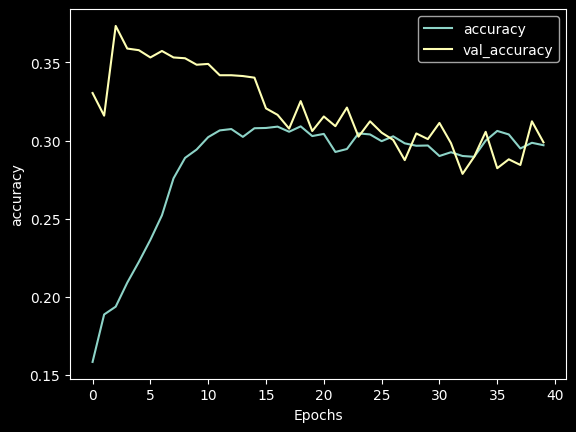

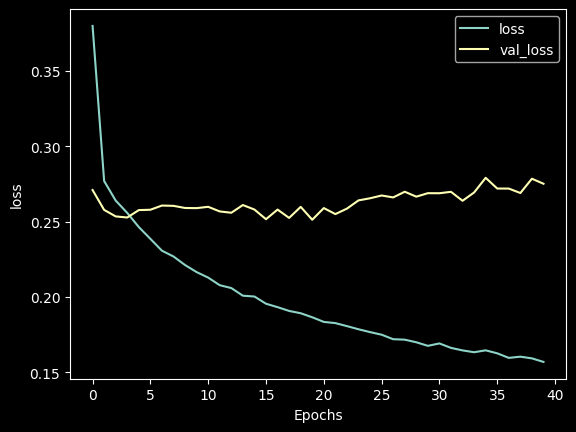

In [48]:
plot_graphs(positive_history, "accuracy")
plot_graphs(positive_history, "loss")



In [49]:
print(train_negative_x.shape)
print(max_length)



(5225, 33)
33


In [50]:
negative_model = Sequential()
negative_model.add(Embedding(vocab_size, 16, input_length=max_length))
negative_model.add(Dropout(0.5))
negative_model.add(Bidirectional(LSTM(20)))
negative_model.add(Dropout(0.5))
negative_model.add(Dense(max_length, activation="softmax"))
negative_model.compile(
    loss=l, optimizer=tf.keras.optimizers.Adam(0.001), metrics=["accuracy"]
)
negative_history = negative_model.fit(
    train_negative_x.astype(float),
    train_negative_y.astype(float),
    epochs=40,
    verbose=2,
    validation_data=(
        validate_negative_x.astype(float),
        validate_negative_y.astype(float),
    ),
)



Epoch 1/40
164/164 - 3s - 19ms/step - accuracy: 0.0886 - loss: 0.4135 - val_accuracy: 0.0936 - val_loss: 0.3052
Epoch 2/40
164/164 - 1s - 5ms/step - accuracy: 0.1102 - loss: 0.3052 - val_accuracy: 0.1821 - val_loss: 0.2821
Epoch 3/40
164/164 - 1s - 5ms/step - accuracy: 0.1118 - loss: 0.2874 - val_accuracy: 0.1330 - val_loss: 0.2754
Epoch 4/40
164/164 - 1s - 5ms/step - accuracy: 0.1039 - loss: 0.2766 - val_accuracy: 0.1234 - val_loss: 0.2718
Epoch 5/40
164/164 - 1s - 5ms/step - accuracy: 0.1185 - loss: 0.2649 - val_accuracy: 0.0998 - val_loss: 0.2715
Epoch 6/40
164/164 - 1s - 5ms/step - accuracy: 0.1215 - loss: 0.2549 - val_accuracy: 0.0986 - val_loss: 0.2776
Epoch 7/40
164/164 - 1s - 5ms/step - accuracy: 0.1231 - loss: 0.2464 - val_accuracy: 0.1319 - val_loss: 0.2768
Epoch 8/40
164/164 - 1s - 5ms/step - accuracy: 0.1049 - loss: 0.2382 - val_accuracy: 0.1048 - val_loss: 0.2785
Epoch 9/40
164/164 - 1s - 5ms/step - accuracy: 0.1114 - loss: 0.2333 - val_accuracy: 0.1229 - val_loss: 0.2779


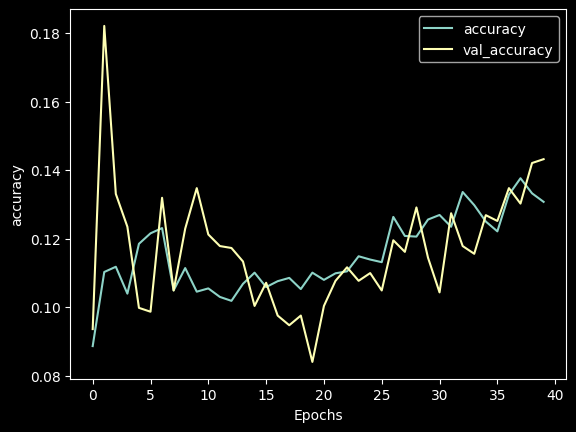

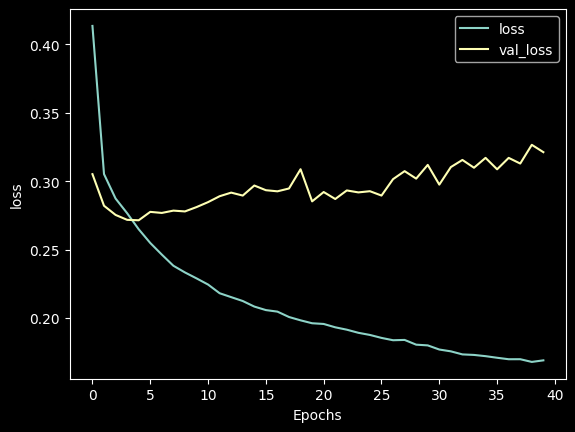

In [51]:
plot_graphs(negative_history, "accuracy")
plot_graphs(negative_history, "loss")




In [52]:
def probs_to_topk_mask(probs_1d: np.ndarray, k: int) -> np.ndarray:
    # Change (score): previously argmax produced a single-word selection, hurting word-level Jaccard.
    # Selecting top-k positions is still a mask over positions (same evaluation semantics),
    # but yields multi-word phrases more consistent with ground truth.
    probs_1d = np.asarray(probs_1d).reshape(-1)
    mask = np.zeros_like(probs_1d, dtype=np.int32)
    if probs_1d.size == 0:
        return mask
    k = int(max(1, min(k, probs_1d.size)))
    topk_idx = np.argpartition(-probs_1d, kth=k - 1)[:k]
    mask[topk_idx] = 1
    return mask


def effective_token_len(padded_row: np.ndarray) -> int:
    padded_row = np.asarray(padded_row).reshape(-1)
    nz = np.flatnonzero(padded_row != 0)
    return int(nz[-1] + 1) if nz.size else 0


val_neg_preds = []
for item in validate_negative_x:
    p = negative_model.predict(item[np.newaxis], verbose=0)  # (1, max_length)
    p = np.asarray(p).reshape(-1)
    L = effective_token_len(item)
    k = max(1, min(6, int(round(0.35 * max(L, 1)))))  # bounded, length-aware
    val_neg_preds.append(probs_to_topk_mask(p, k=k))
val_neg_preds = np.array(val_neg_preds, dtype=np.int32)


def check_negative(index):
    print(list(validation.text[validation.sentiment == "negative"])[index])
    print(get_phrase(validate_negative_x, val_neg_preds, index))




In [53]:
test = pd.read_csv("../input/tweet-sentiment-extraction/test.csv")
test_raw_text = test["text"].astype(str).values.copy()
clean_text(test, "text")



2749


In [54]:
test_sequences = tokenizer.texts_to_sequences(test.text.astype(str).values)
test_padded = pad_sequences(
    test_sequences, truncating=trunc_type, maxlen=max_length, padding=pad_type
)



In [55]:
preds = []
for index, item in enumerate(test_padded):
    sent = test.sentiment.iloc[index]
    L = effective_token_len(item)
    k = max(1, min(6, int(round(0.35 * max(L, 1)))))  # bounded, length-aware
    if sent == "positive":
        p = positive_model.predict(item[np.newaxis], verbose=0)
        p = np.asarray(p).reshape(-1)
        preds.append(probs_to_topk_mask(p, k=k))
    elif sent == "negative":
        p = negative_model.predict(item[np.newaxis], verbose=0)
        p = np.asarray(p).reshape(-1)
        preds.append(probs_to_topk_mask(p, k=k))
    else:
        preds.append(np.zeros((max_length,), dtype=np.int32))

preds = np.array(preds, dtype=np.int32)




In [56]:
def phrase_to_string(words_arr):
    s = " ".join([w for w in list(words_arr) if w is not None and w != ""]).strip()
    return s


def select_span_from_raw_by_words(raw_text: str, cleaned_words: list) -> str:
    # Change (score): competition expects exact substring with punctuation/casing.
    # We map predicted cleaned tokens back to raw tokens and return the minimal contiguous span.
    if raw_text is None:
        return ""
    raw_text = str(raw_text)
    if not cleaned_words:
        return raw_text.strip()

    raw_tokens = raw_text.split()
    if len(raw_tokens) == 0:
        return raw_text.strip()

    cleaned_tokens = [_clean_one(t) for t in raw_tokens]
    target = [str(w) for w in cleaned_words if str(w).strip() != ""]
    if not target:
        return raw_text.strip()

    # find earliest and latest matched positions in order (greedy)
    pos = []
    j = 0
    for i, ct in enumerate(cleaned_tokens):
        if j < len(target) and ct == target[j]:
            pos.append(i)
            j += 1
            if j == len(target):
                break

    if not pos:
        return raw_text.strip()

    start, end = pos[0], pos[-1]
    return " ".join(raw_tokens[start : end + 1]).strip()


pred_texts = []
for i in range(len(test)):
    if test.sentiment.iloc[i] == "neutral":
        pred_texts.append(test_raw_text[i].strip())
    else:
        words = get_phrase(test_padded, preds, i)
        cleaned_phrase = phrase_to_string(words)
        if cleaned_phrase == "":
            pred_texts.append(test_raw_text[i].strip())
        else:
            raw_span = select_span_from_raw_by_words(
                test_raw_text[i], cleaned_phrase.split()
            )
            if raw_span == "":
                raw_span = test_raw_text[i].strip()
            pred_texts.append(raw_span)

test["prediction"] = pred_texts



In [57]:
evaluation = test[["textID"]].copy()
evaluation["selected_text"] = test["prediction"].astype(str)

evaluation.to_csv("submission.csv", index=False)

print(evaluation.head())
print("Wrote submission.csv with shape:", evaluation.shape)
print("submission.csv saved to:", os.path.abspath("submission.csv"))

       textID                                      selected_text
0  80a1e6bc32                                  star... I made my
1  863097735d                      gosh today sucks! i didnt get
2  264cd5277f  tired and didn`t really have an exciting Satur...
3  baee1e6ffc             i`ve been eating cheetos all morning..
4  67d06a8dee  haiiii sankQ i`m fineee ima js get a checkup c...
Wrote submission.csv with shape: (2749, 2)
submission.csv saved to: /kaggle/working/submission.csv
